# Some ramblings about Gaussians.

Specifically, products of Gaussian RVs, products of their densities, and relation with joint distributions of (independent) Gaussian marginals.

## Product of Gaussians is a (scaled) Gaussian.

In Section 6.5.2 it is stated that

\begin{equation}N(x|a,A)N(x|b,B) = \gamma N(x|c,C)\end{equation}

where $\gamma, c$, and $C$ can be expressed in terms of $a,b,A,B$. In particular, one may write $\gamma = N(a|b,A+B)$ (this is an abuse of notation)


Now, there are two ways one may try to interpret this, at least someone (i.e., me) with extremely limited prior statistics knowledge and intuition. The first is as a product of Gaussian RVs (this is wrong), and the second is a product of Gaussian density functions (this is correct).

This is where it clicked for me (perhaps later than it should have) that random variables (RVs) and density functions are *very* different things.

### Does this mean a product of Gaussian RVs? (No)

The above product **does not** refer to a product of RVs with distrubitions $N(a,A)$ and $N(b,B)$.

For example, let $X \sim N(0,1)$ (1 dimensional Gaussian). This has the following (density function) distribution.


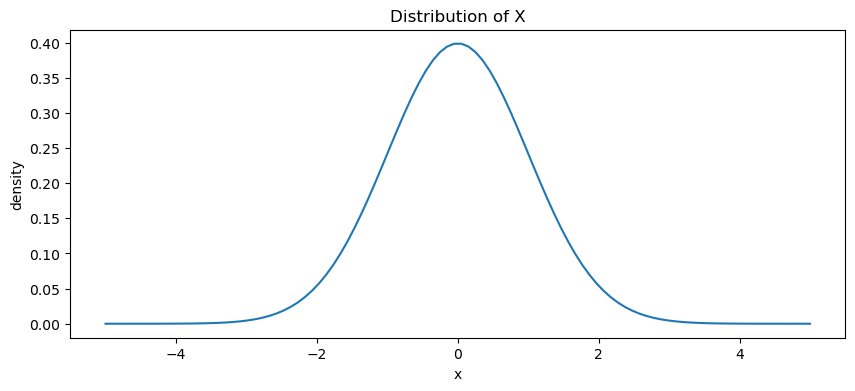

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x_vals = np.linspace(-5, 5, 100)

pdf = norm.pdf(x_vals,0,1)

plt.figure(figsize=(10,4))
plt.plot(x_vals, pdf)
plt.title('Distribution of X')
plt.xlabel('x')
plt.ylabel('density')
plt.show()

Now, consider $Y := X^2$. Consider this as a function $Y: \Omega \rightarrow \mathbb{R}$ (same domain and codomain as $X$). Then for any $y \in \mathbb{R}$ we have:

$$\mathbb{P}(Y \leq y) = \mathbb{P}(X^2 \leq y) = \mathbb{P}(-\sqrt{y} \leq X \leq \sqrt{y})$$

Thus, the CDF is given by $F_Y(y) = \begin{cases} \int_{-\sqrt{y}}^\sqrt{y} f_X(x) \text{d}x = 2\int_{0}^\sqrt{y} f_X(x) \text{d}x& y\geq0\\ 0 & y\leq0\end{cases}.$

The fundamental theorem of calculus yields $f_Y(y) = \begin{cases} 2f_X(\sqrt{y})\cdot \frac{\text{d}}{\text{dy}}(\sqrt{y}) = \frac{1}{\sqrt{y}}\cdot f_X(\sqrt{y})& y>0\\ 0& y \leq 0\end{cases}.$

This density looks like the following (note that it is clearly not Gaussian, as it is non-zero only when $y>0$):

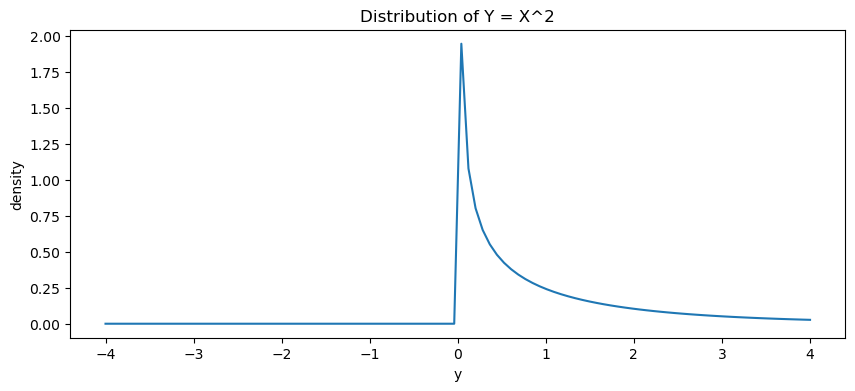

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x_vals = np.linspace(-4, 4, 100)

def y_pdf(x:float):
    return norm.pdf(np.sqrt(x),0,1)/np.sqrt(x) if x>0 else 0

pdf = [y_pdf(x) for x in x_vals]

plt.figure(figsize=(10,4))
plt.plot(x_vals, pdf)
plt.title('Distribution of Y = X^2')
plt.xlabel('y')
plt.ylabel('density')
plt.show()

In short, the product of two Gaussian RVs is not Gaussian distributed.

### Does it mean product of density functions of Gaussians (Yes!)

In fact, $N(x|a,A)N(x|b,B) = \gamma N(x|c,C)$ refers to the product of the density functions, say $p$ and $q$ at the point $x$. i.e., $N(x|a,A)N(x|b,B) = p(x)q(x)$ where $p \sim N(x|a,A)$ and $q \sim N(x|b,B)$.

The result is that $d(x) := p(x)q(x)$ (once scaled by $\gamma^{-1}$) is Gaussian distributed.

Example: $p = q \sim N(3,3)$, so $d(x) = p(x)^2$

Warning: scipy.stats.norm.pdf uses standard deviation as parameter, whereas we use variation as parameter.

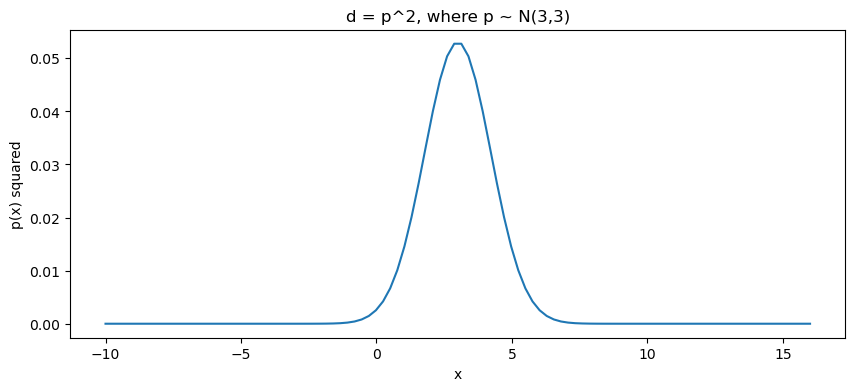

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.integrate import quad

x_vals = np.linspace(-10, 16, 100)

square_of_pdf = [norm.pdf(x, 3, np.sqrt(3))**2 for x in x_vals]

plt.figure(figsize=(10,4))
plt.plot(x_vals, square_of_pdf)
plt.title('d = p^2, where p ~ N(3,3)')
plt.xlabel('x')
plt.ylabel('p(x) squared')
plt.show()

Indeed, this looks Gaussian. However, looking at the y-axis scale we see that the area under the curve is much less than $1$ (to convince yourself of this, consider a box with base (-10,10) and height 0.05. This has area 1. The area under the curve is clearly much less than this.)

The factor, $\gamma = N(a|b,A+B) = N(3|3,6)$ should be exactly the area under the curve (since the area under a Gaussian is 1, and the product of densities is distributed by $\gamma N(c,C)$. Let's check this.

In [12]:
from scipy.integrate import quad
import numpy as np
from scipy.stats import norm

area_under_curve, _ = quad(lambda t: norm.pdf(t,3,np.sqrt(3))**2, -np.inf, np.inf)

gamma = norm.pdf(3,3,np.sqrt(6)) #density at a=3 of density with distribution N(3,6)

#We need to give some tolerance, of course (since we use numerical methods).
print(f"Area under the curve is: {area_under_curve}")
print(f"gamma is: {gamma}")
print(f"Equal? (up to small tolerance): {abs(area_under_curve-gamma)<0.1**8}")

Area under the curve is: 0.16286750397942648
gamma is: 0.16286750396764
Equal? (up to small tolerance): True


## Joint distribution of independent Gaussians and its relation to the product of densities $N(x|a,A)N(x|b,B)$

Suppose $X$ and $Y$ are independent RVs with densities $p \sim N(a,A)$ and $q \sim N(b,B)$. Then $(X,Y)$ is (multivariate) Gaussian distributed with density function

$$\textbf{d} = \begin{pmatrix}p \\ q \end{pmatrix} \sim N\left(\begin{pmatrix}a \\ b \end{pmatrix}, \begin{pmatrix}A&0\\0&B \end{pmatrix}\right)$$

Moreover, we have $\mathbf{d}(x,y) = p(x)q(y)$ (since $X$ and $Y$ independent).

Our product of Gaussian densities is given by $\mathbf{d}(x,x)$! In other words, our product of densities is exactly the "$y=x$" slice of the 2d density function, $\mathbb{d}$.

Let's visualise this. Let's use $\textbf{d} \sim N\left(\begin{pmatrix}2 \\ 6 \end{pmatrix}, \begin{pmatrix}10&0\\0&1 \end{pmatrix}\right)$ for our concrete example.

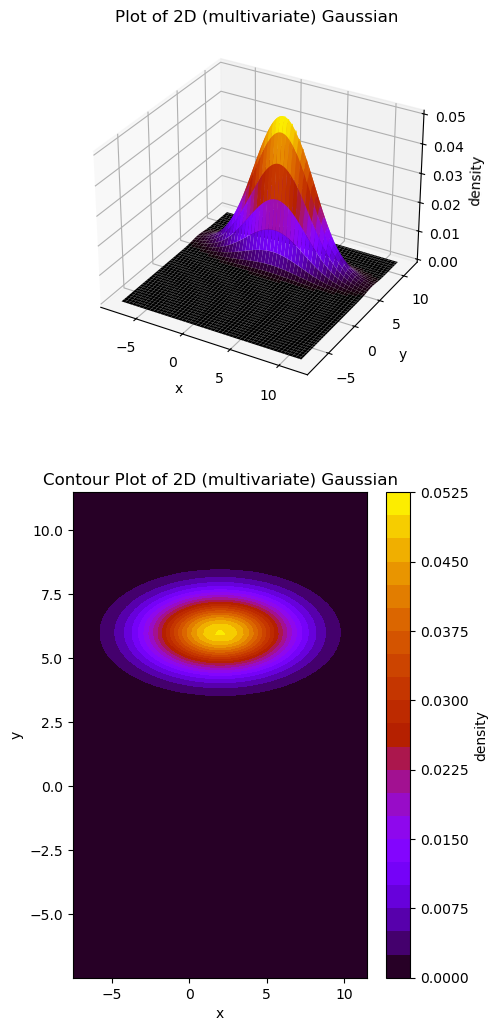

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

mean = [2, 6]
covariance = [[10, 0], [0, 1]]
d = multivariate_normal(mean, covariance)

val_min = min(mean[0]-3*np.sqrt(covariance[0][0]),mean[1]-3*np.sqrt(covariance[1][1]))
val_max = max(mean[0]+3*np.sqrt(covariance[0][0]),mean[1]+3*np.sqrt(covariance[1][1]))

x = np.linspace(val_min, val_max, 100)
X, Y = np.meshgrid(x,x)
coords = np.dstack((X, Y))

Z = d.pdf(coords)

fig = plt.figure(figsize=(5,11))
#projection plot
ax = fig.add_subplot(211, projection='3d')
ax.plot_surface(X, Y, Z, cmap='gnuplot')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('density')
ax.set_title('Plot of 2D (multivariate) Gaussian')

# Contour plot
ax2 = fig.add_subplot(212)
contour = ax2.contourf(X, Y, Z, levels=20, cmap='gnuplot')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Contour Plot of 2D (multivariate) Gaussian')
fig.colorbar(contour, ax=ax2, label='density')

plt.tight_layout()
plt.show()

Finally, let's plot $d(x,x)$ and see that it looks Gaussian with the correct area under curve (i.e. area under curve $= N(a|b, A+B)$)

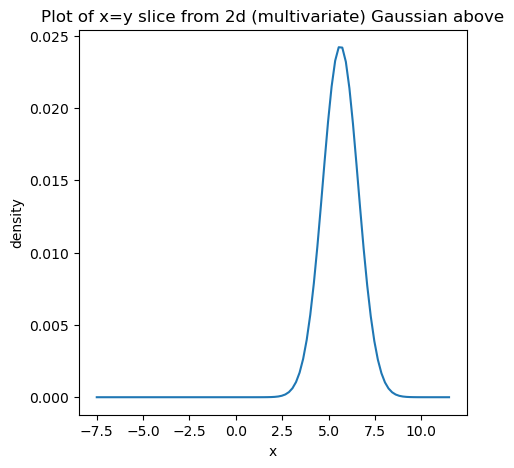

In [33]:
#This cell requires the previous code cell to be run first

x_array = np.linspace(val_min, val_max, 100)

z = [d.pdf([x,x]) for x in x_array]

plt.figure(figsize=(5,5))
plt.plot(x_array, z)
plt.title('Plot of x=y slice from 2d (multivariate) Gaussian above')
plt.xlabel('x')
plt.ylabel('density')
plt.show()

and areas under curves (both numerically, and using expression for $\gamma$) are ...

In [19]:
#This cell requires the code cell two previous to be run first

from scipy.integrate import quad
import numpy as np
from scipy.stats import norm

area_under_curve, _ = quad(lambda t: d.pdf([t,t]), -np.inf, np.inf)

#gamma = N(a|b,A+B). Thus the code required is gamma = norm.pdf(a,b,sqrt(A+B))
gamma = norm.pdf(mean[0],mean[1],np.sqrt(covariance[0][0]+covariance[1][1]))

print(f"Area under the curve is: {area_under_curve}")
print(f"gamma is: {gamma}")
print(f"Equal? (up to small tolerance): {abs(area_under_curve-gamma)<0.1**8}")

Area under the curve is: 0.05812503012026839
gamma is: 0.05812503012026839
Equal? (up to small tolerance): True
